In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Cell 1 - Imports & Settings
import os
import random
from pathlib import Path
import shutil
import csv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# Paths (edit DATASET_PATH to your local/colab dataset)
DATASET_PATH = "/content/drive/MyDrive/celeba_hq_256"     # <-- change this
OUT_ROOT = "/content/drive/MyDrive/celeba_hq_splits" # output splits + degraded images # <-- change this
os.makedirs(OUT_ROOT, exist_ok=True)

# Split ratios
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

# Degradation settings (you can change these)
NOISE_SIGMA_CHOICES = [10, 15, 20, 30]
BLUR_KERNELS = [3, 5, 7]
JPEG_QUALITIES = [30, 40, 60]

In [4]:
# ======================================================
# Cell 2 - Gather file list & basic sanity checks
# ======================================================
all_files = sorted([f for f in os.listdir(DATASET_PATH) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
n_total = len(all_files)
print(f"Found {n_total} image files in {DATASET_PATH}")

# quick guard
if n_total == 0:
    raise ValueError("No images found. Check DATASET_PATH.")

Found 30000 image files in /content/drive/MyDrive/celeba_hq_256


In [5]:
# ======================================================
# Cell 3 - Compute image sizes for a quick distribution check
# ======================================================
# We'll sample up to 1000 images to compute stats quickly
sample_files = all_files if n_total <= 1000 else random.sample(all_files, 1000)

size_counter = Counter()
pixel_counts = []
for fname in tqdm(sample_files, desc="Collecting image sizes"):
    img = cv2.imread(os.path.join(DATASET_PATH, fname))
    if img is None:
        continue
    h, w = img.shape[:2]
    size_counter[(h, w)] += 1
    pixel_counts.append(h * w)

print("Unique sizes (sample):", list(size_counter.items())[:6])
print("Average pixels (sample):", int(np.mean(pixel_counts)))
print("Min pixels (sample):", int(np.min(pixel_counts)))
print("Max pixels (sample):", int(np.max(pixel_counts)))

Unique sizes (sample): [((256, 256), 1000)]
Average pixels (sample): 65536
Min pixels (sample): 65536
Max pixels (sample): 65536


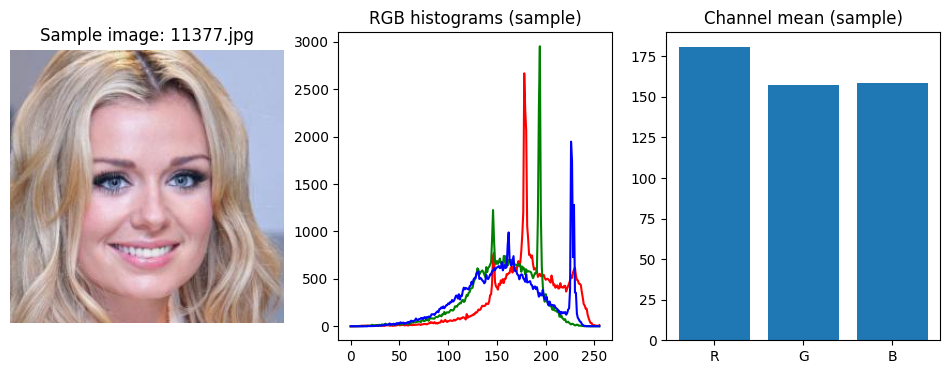

In [6]:
# ======================================================
# Cell 4 - RGB channel histograms (plot for a random sample)
# ======================================================
# Take one representative image
rep_fname = random.choice(all_files)
rep_img = cv2.cvtColor(cv2.imread(os.path.join(DATASET_PATH, rep_fname)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(rep_img); plt.title(f"Sample image: {rep_fname}"); plt.axis("off")
plt.subplot(1,3,2)
for i, col in enumerate(('r','g','b')):
    hist = cv2.calcHist([rep_img],[i],None,[256],[0,256])
    plt.plot(hist, color=col)
plt.title("RGB histograms (sample)")
plt.subplot(1,3,3)
# show channel means as bar
means = rep_img.mean(axis=(0,1))
plt.bar(['R','G','B'], means); plt.title("Channel mean (sample)")
plt.show()

In [7]:
# ======================================================
# Cell 5 - Global mean/std across a subset (for normalization)
# ======================================================
# compute over up to 2000 images to save time
subset = all_files if n_total <= 2000 else random.sample(all_files, 2000)
cumul_mean = np.zeros(3)
cumul_var = np.zeros(3)
n_pix_total = 0

for fname in tqdm(subset, desc="Computing global mean/std"):
    img = cv2.cvtColor(cv2.imread(os.path.join(DATASET_PATH, fname)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    h, w, _ = img.shape
    px = h * w
    cumul_mean += img.reshape(-1,3).sum(axis=0)
    cumul_var += (img.reshape(-1,3) ** 2).sum(axis=0)
    n_pix_total += px

global_mean = cumul_mean / n_pix_total
global_var = cumul_var / n_pix_total - global_mean**2
global_std = np.sqrt(global_var)
print("Global mean (RGB):", global_mean)
print("Global std (RGB):", global_std)


Computing global mean/std: 100%|██████████| 2000/2000 [00:21<00:00, 92.72it/s]

Global mean (RGB): [0.51688915 0.41493086 0.36195727]
Global std (RGB): [0.30174605 0.27321394 0.268457  ]


In [8]:
# ======================================================
# Cell 6 - Split dataset into train/val/test (deterministic shuffle)
# ======================================================
files_shuffled = all_files.copy()
random.shuffle(files_shuffled)  # deterministic due to seed set earlier

n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

train_files = files_shuffled[:n_train]
val_files = files_shuffled[n_train:n_train + n_val]
test_files = files_shuffled[n_train + n_val:]

print(f"Split counts: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

# Create folders to store splits and degraded images
for split in ("train","val","test"):
    os.makedirs(os.path.join(OUT_ROOT, split, "clean"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, split, "degraded"), exist_ok=True)

# Copy clean images into split folders
def copy_list(file_list, out_clean_folder):
    for fname in tqdm(file_list, desc=f"Copying to {out_clean_folder}"):
        src = os.path.join(DATASET_PATH, fname)
        dst = os.path.join(out_clean_folder, fname)
        shutil.copy2(src, dst)

copy_list(train_files, os.path.join(OUT_ROOT, "train", "clean"))
copy_list(val_files, os.path.join(OUT_ROOT, "val", "clean"))
copy_list(test_files, os.path.join(OUT_ROOT, "test", "clean"))

Split counts: train=24000, val=3000, test=3000


Copying to /content/drive/MyDrive/celeba_hq_splits/train/clean: 100%|██████████| 24000/24000 [07:02<00:00, 56.77it/s]
Copying to /content/drive/MyDrive/celeba_hq_splits/val/clean: 100%|██████████| 3000/3000 [00:55<00:00, 54.24it/s]
Copying to /content/drive/MyDrive/celeba_hq_splits/test/clean: 100%|██████████| 3000/3000 [01:00<00:00, 49.37it/s]


In [9]:
# ======================================================
# Cell 7 - Degradation functions
# ======================================================
def add_gaussian_noise(img, sigma=20):
    """img: uint8 RGB"""
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    out = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return out

def apply_blur(img, ksize=5):
    k = (ksize, ksize)
    return cv2.GaussianBlur(img, k, 0)

def apply_jpeg_compression(img, quality=40):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)]
    _, encimg = cv2.imencode('.jpg', img, encode_param)
    return cv2.imdecode(encimg, 1)

def reduce_lighting(img, scale=0.8):
    """Reduce image lighting by a scale factor."""
    return np.clip(img.astype(np.float32) * scale, 0, 255).astype(np.uint8)

def random_degrade(img, deterministic_seed=None):
    """Apply a reproducible random degradation and return parameters used"""
    if deterministic_seed is not None:
        np.random.seed(deterministic_seed)

    # Apply blur, noise, and jpeg compression
    k = int(np.random.choice(BLUR_KERNELS))
    s1 = int(np.random.choice(NOISE_SIGMA_CHOICES))
    s2 = int(np.random.choice([40, 50, 60])) # Additional noise degradation
    q = int(np.random.choice(JPEG_QUALITIES))
    light_scale = np.random.uniform(0.5, 0.9) # Random lighting reduction scale

    out = apply_blur(img, ksize=k)
    out = add_gaussian_noise(out, sigma=s1)
    out = add_gaussian_noise(out, sigma=s2) # Apply additional noise
    out = apply_jpeg_compression(out, quality=q)
    out = reduce_lighting(out, scale=light_scale) # Apply lighting reduction

    return out, {"blur_k": k, "noise_sigma_1": s1, "noise_sigma_2": s2, "jpeg_q": q, "light_scale": light_scale}

In [10]:
# ======================================================
# Cell 8 - Create degraded images for each split & save mapping CSV
# ======================================================
mapping_csv = os.path.join(OUT_ROOT, "degradation_map.csv")
with open(mapping_csv, "w", newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=["split","filename","blur_k","noise_sigma_1","noise_sigma_2","jpeg_q", "light_scale"]) # Updated fieldnames
    writer.writeheader()

    for split, file_list in (("train", train_files), ("val", val_files), ("test", test_files)):
        out_degraded_dir = os.path.join(OUT_ROOT, split, "degraded")
        out_clean_dir = os.path.join(OUT_ROOT, split, "clean")
        for i, fname in enumerate(tqdm(file_list, desc=f"Degrading {split}")):
            src = os.path.join(out_clean_dir, fname)
            img = cv2.cvtColor(cv2.imread(src), cv2.COLOR_BGR2RGB)
            # deterministic seed per image so mapping is reproducible
            seed_for_image = (hash(fname) + SEED) % (2**32)
            degraded_img, params = random_degrade(img, deterministic_seed=seed_for_image)
            # save degraded as RGB
            save_path = os.path.join(out_degraded_dir, fname)
            cv2.imwrite(save_path, cv2.cvtColor(degraded_img, cv2.COLOR_RGB2BGR))
            # log mapping
            writer.writerow({"split": split, "filename": fname,
                             "blur_k": params["blur_k"],
                             "noise_sigma_1": params["noise_sigma_1"],
                             "noise_sigma_2": params["noise_sigma_2"],
                             "jpeg_q": params["jpeg_q"],
                             "light_scale": params["light_scale"]}) # Updated parameter logging
print("Saved degradation mapping to:", mapping_csv)

Degrading test: 100%|██████████| 3000/3000 [02:11<00:00, 22.87it/s]

Saved degradation mapping to: /content/drive/MyDrive/celeba_hq_splits/degradation_map.csv


In [11]:
# ======================================================
# Cell 9 - Quick visualization of random triplets from each split
# ======================================================
def show_triplet(split, n=4):
    clean_dir = os.path.join(OUT_ROOT, split, "clean")
    deg_dir = os.path.join(OUT_ROOT, split, "degraded")
    files = sorted([f for f in os.listdir(clean_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    picks = random.sample(files, n)
    for fname in picks:
        clean = cv2.cvtColor(cv2.imread(os.path.join(clean_dir, fname)), cv2.COLOR_BGR2RGB)
        deg = cv2.cvtColor(cv2.imread(os.path.join(deg_dir, fname)), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1); plt.imshow(deg); plt.title(f"{split} degraded: {fname}"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(clean); plt.title("clean ground truth"); plt.axis("off")
        plt.show()

print("Train examples:")
show_triplet("train", n=3)
print("Val examples:")
show_triplet("val", n=3)
print("Test examples:")
show_triplet("test", n=3)

Output hidden; open in https://colab.research.google.com to view.

In [12]:
# ======================================================
# Cell 10 - Sanity check counts and a CSV manifest of splits
# ======================================================
manifest_csv = os.path.join(OUT_ROOT, "split_manifest.csv")
with open(manifest_csv, "w", newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=["filename","split","clean_path","degraded_path"])
    writer.writeheader()
    for split, file_list in (("train", train_files), ("val", val_files), ("test", test_files)):
        for fname in file_list:
            clean_p = os.path.join(OUT_ROOT, split, "clean", fname)
            deg_p = os.path.join(OUT_ROOT, split, "degraded", fname)
            writer.writerow({"filename": fname, "split": split, "clean_path": clean_p, "degraded_path": deg_p})
print("Saved split manifest to:", manifest_csv)

Saved split manifest to: /content/drive/MyDrive/celeba_hq_splits/split_manifest.csv


In [13]:
# ======================================================
# Notebook end - Summary
# ======================================================
print("Done. Dataset split and degradations created under:", OUT_ROOT)
print("Train/Val/Test sizes:", len(train_files), len(val_files), len(test_files))


Done. Dataset split and degradations created under: /content/drive/MyDrive/celeba_hq_splits
Train/Val/Test sizes: 24000 3000 3000
